# This Notebook Aims to Modify the Inputs

The updates will be performed initially on the 'clean_data.csv'

## Importing

In [1]:
from pathlib import Path
import sys
root= Path.cwd().parent
sys.path.append(str(root))
from src.graph import univariate_plot
from src.clean import log_transform,  standard_scaling

import pandas as pd

In [2]:
data = pd.read_csv('../data/processed/clean_data.csv')

## Adding New Inputs

Adding the input 'rooms_per_household'

In [3]:
data["rooms_per_household"] = data["total_rooms"] / data["households"]

Adding the input 'bedrooms_per_room', which is the proportion of bedrooms

In [4]:
data['bedrooms_per_room'] = data["total_bedrooms"] / data["total_rooms"]

Adding the input 'population_per_household', which is the proportion of bedrooms

In [5]:
data['population_per_household'] = data['population'] / data['households']

Reorder the columns to make the boolean columns last

In [6]:
data= data[
    list(data.columns[0:9]) +
    list(data.columns[14:]) +
    list(data.columns[9:14])
]

Check a sample

In [7]:
data.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,bedrooms_per_room,population_per_household,<1h ocean,inland,near ocean,island,rooms_per_household
4971,-118.28,34.01,48.0,483.0,190.0,775.0,188.0,2.3309,126600.0,0.393375,4.122340,1,0,0,0,2.569149
12935,-121.28,38.66,17.0,7741.0,1401.0,3153.0,1331.0,3.7869,216100.0,0.180984,2.368896,0,1,0,0,5.815928
3153,-118.46,35.12,16.0,4084.0,812.0,2033.0,668.0,3.2405,85500.0,0.198825,3.043413,0,1,0,0,6.113772
9090,-118.22,34.66,17.0,3810.0,662.0,1867.0,586.0,4.9000,152400.0,0.173753,3.186007,0,1,0,0,6.501706
11155,-117.97,33.83,16.0,2035.0,564.0,1118.0,503.0,3.2546,187500.0,0.277150,2.222664,1,0,0,0,4.045726


## Re-Visualize the Old Columns and Visualize Newer Ones as Histograms and BoxPlots

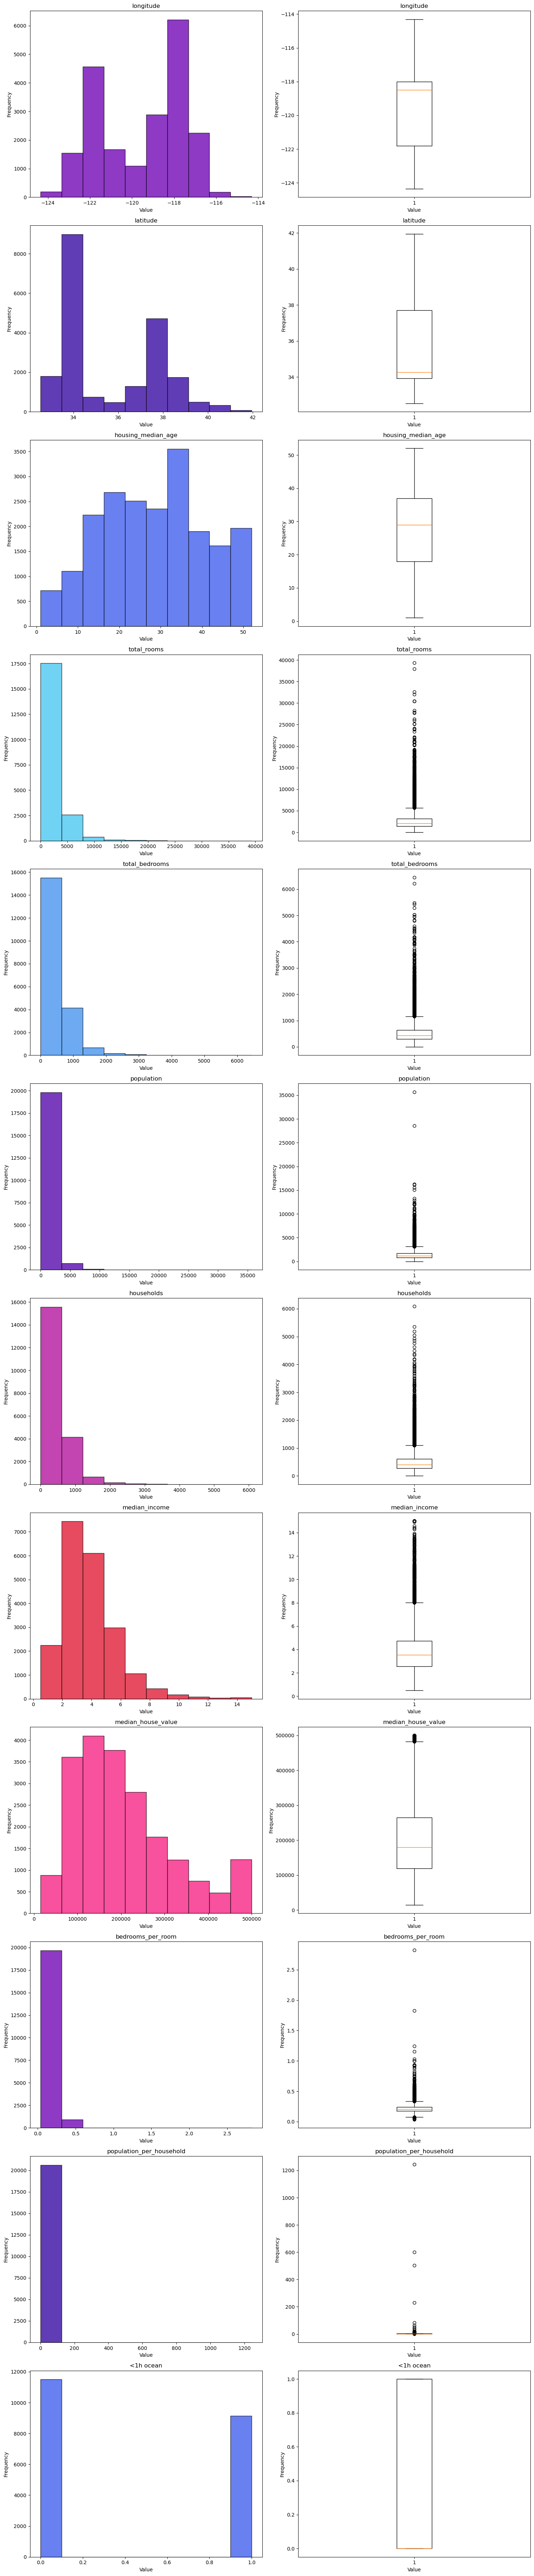

In [8]:
univariate_plot(data, 0, 12)

## Modifying the Skewed Columns using Log Transformation

In [9]:
data = log_transform(data, ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income'])

In [10]:
data.sample(5)

,longitude,latitude,housing_median_age,median_house_value,bedrooms_per_room,population_per_household,<1h ocean,inland,near ocean,island,rooms_per_household,log_total_rooms,log_total_bedrooms,log_population,log_households,log_median_income
5112,-118.29,33.97,48.0,134200.0,0.187002,2.606719,1,0,0,0,6.203557,8.051978,6.376727,7.185387,6.228511,1.508689
1690,-122.24,38.01,11.0,269400.0,0.150626,3.511712,0,0,0,0,6.758559,8.230044,6.338594,7.575585,6.320768,1.914891
11743,-121.08,38.85,10.0,220100.0,0.168194,2.665810,0,1,0,0,6.449871,7.828038,6.047372,6.945051,5.966147,1.945910
8196,-118.13,33.79,20.0,242900.0,0.269093,2.267042,0,0,1,0,4.176360,8.806724,7.494430,8.195885,7.377759,1.562682
20509,-121.53,38.60,25.0,80200.0,0.214397,2.978565,0,1,0,0,4.803355,8.547722,7.008505,8.069968,6.979145,1.323514


Reorder columns

In [11]:
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'median_house_value',
       'bedrooms_per_room', 'population_per_household', '<1h ocean', 'inland',
       'near ocean', 'island', 'rooms_per_household', 'log_total_rooms',
       'log_total_bedrooms', 'log_population', 'log_households',
       'log_median_income'],
      dtype='object')

In [12]:
data = data[
    list(data.columns[0:7])+
    list(data.columns[12:])+
    list(data.columns[7:12])
]

In [13]:
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'median_house_value',
       'bedrooms_per_room', 'population_per_household', '<1h ocean',
       'log_total_bedrooms', 'log_population', 'log_households',
       'log_median_income', 'inland', 'near ocean', 'island',
       'rooms_per_household', 'log_total_rooms'],
      dtype='object')

## Revisualize Transformed Columns

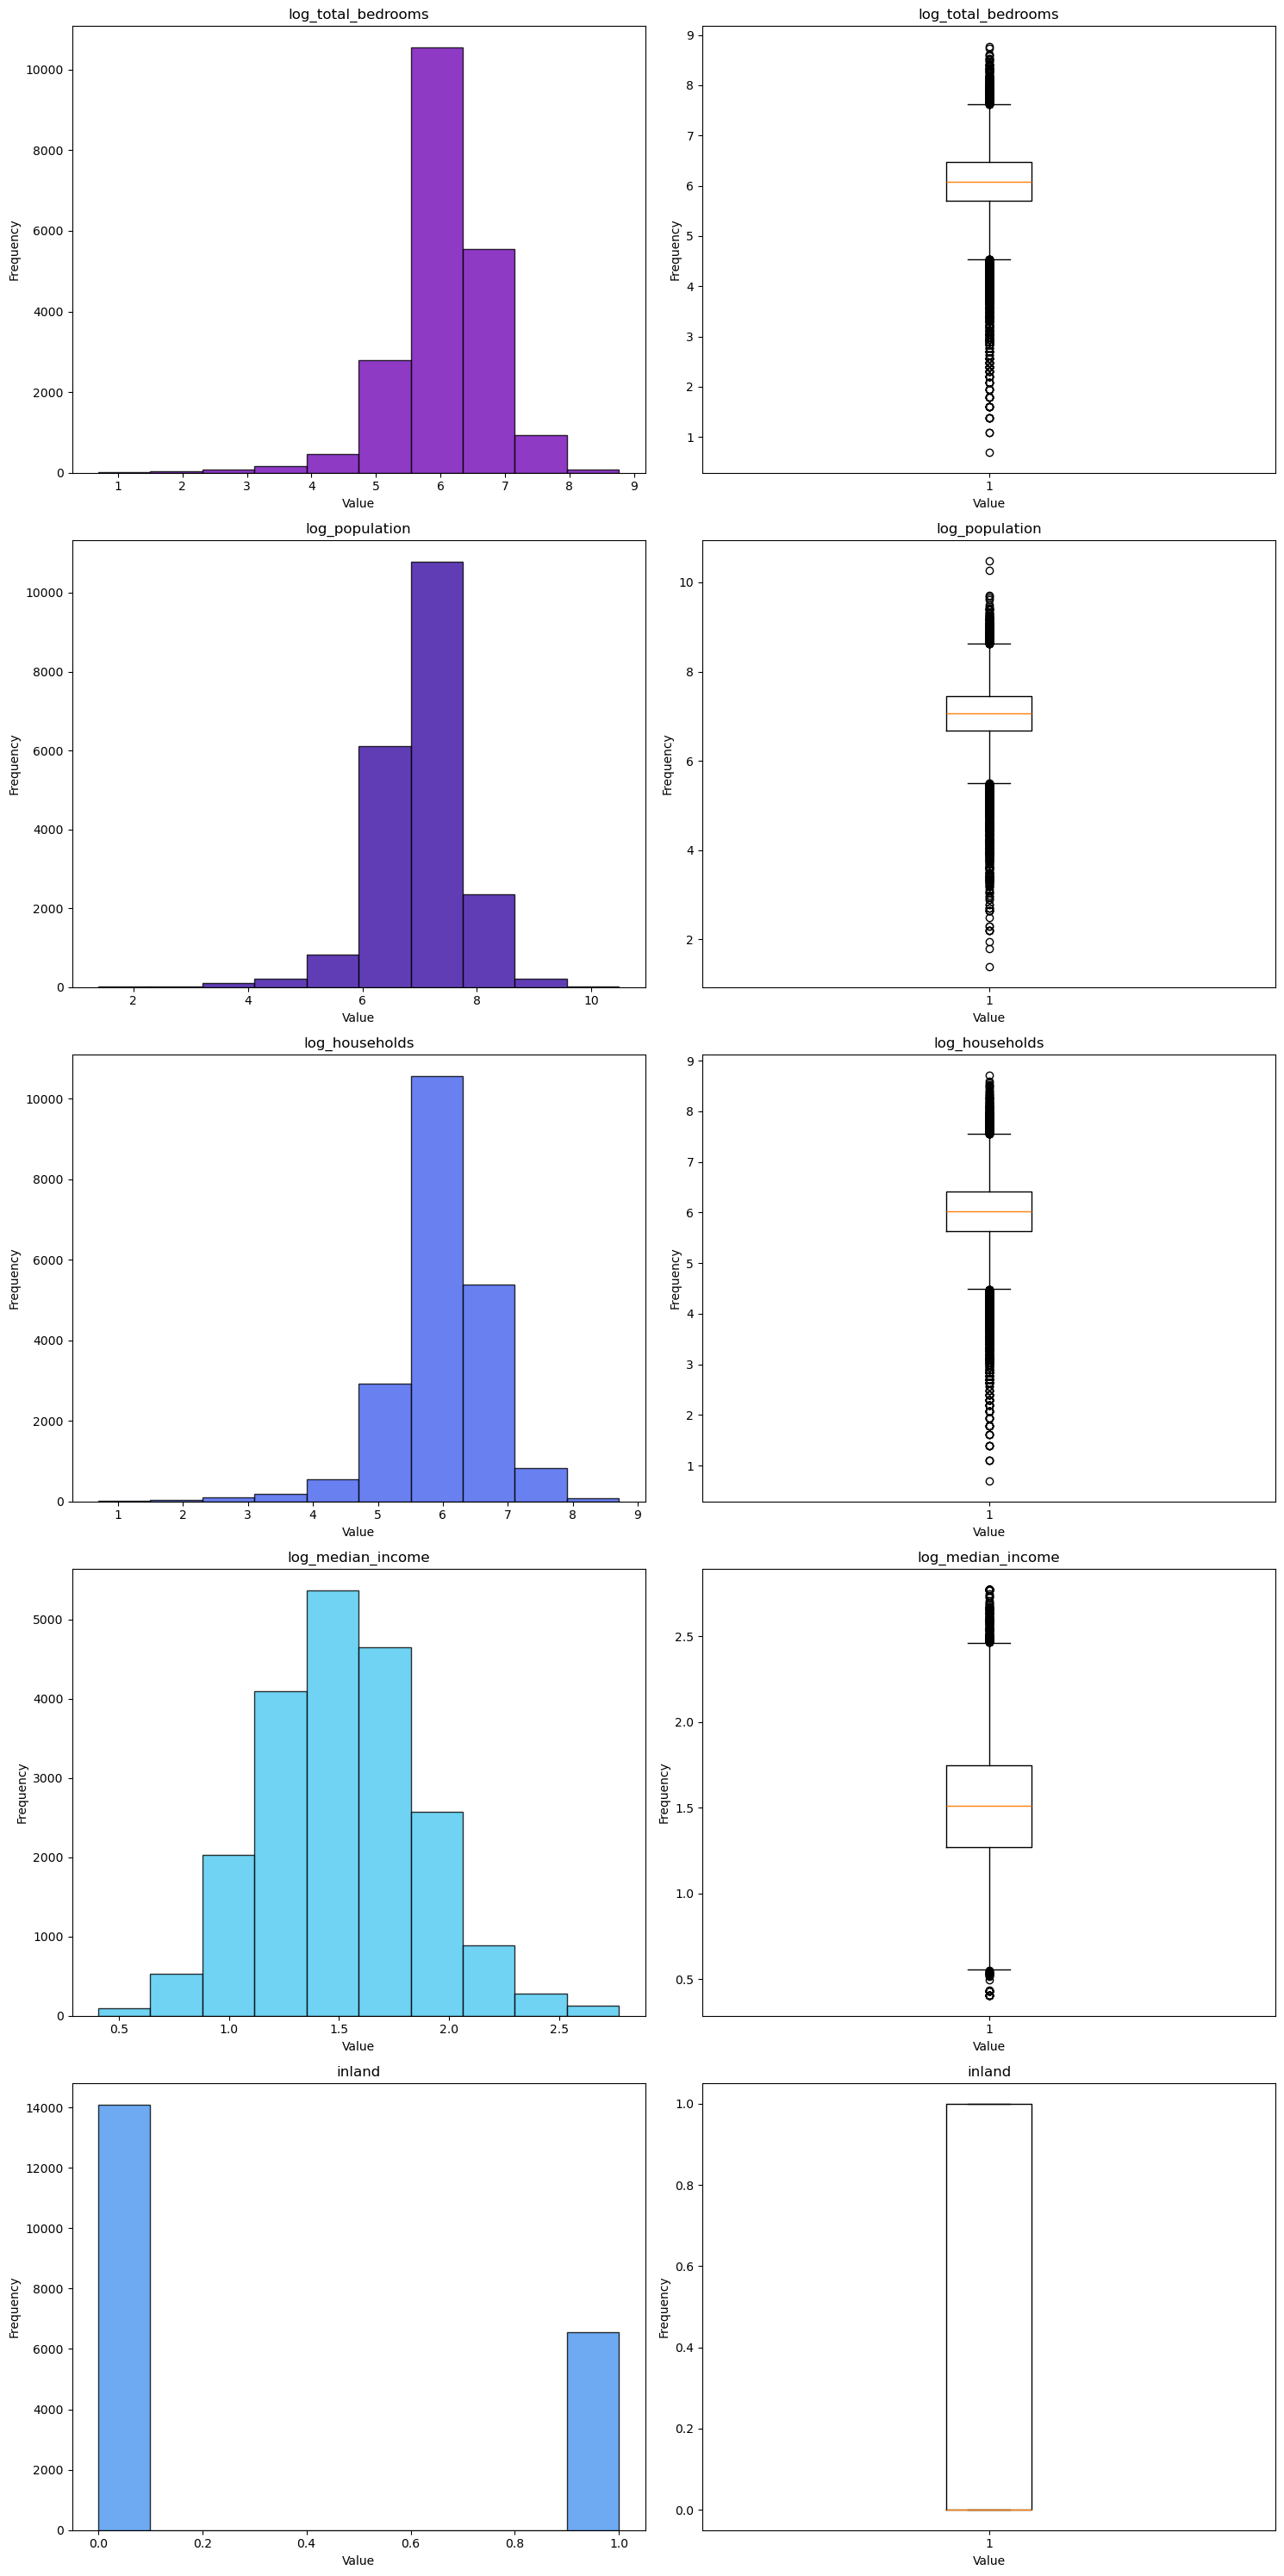

In [14]:
univariate_plot(data, 7, 12)

## Scaling Columns

First 9 columns are scaled using Standard Scaling

In [15]:
data, stats = standard_scaling(data, 0, 9)

c:\Users\PC\Documents\House Prediction\src\clean.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0       -0.891134
1       -0.891134
2       -0.891134
3       -0.891134
4       -0.891134
           ...   
20635   -0.891134
20636   -0.891134
20637   -0.891134
20638   -0.891134
20639   -0.891134
Name: <1h ocean, Length: 20640, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataset.iloc[:, i] = (dataset.iloc[:, i] - og_mean) / og_std


In [16]:
#checking
data.describe()

,longitude,latitude,housing_median_age,median_house_value,bedrooms_per_room,population_per_household,<1h ocean,log_total_bedrooms,log_population,log_households,log_median_income,inland,near ocean,island,rooms_per_household,log_total_rooms
count,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-8.592610e-15,2.269330e-15,6.609700e-17,-9.914550e-17,1.542263e-16,3.786807e-18,1.542263e-16,8.262125e-17,-9.501444e-16,5.984702,1.516995,0.317393,0.128779,0.000242,5.429000,7.629377
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.726740,0.358677,0.465473,0.334963,0.015563,2.474173,0.749991
min,-2.385935e+00,-1.447533e+00,-2.196127e+00,-1.662601e+00,-2.707251e+00,-2.289944e-01,-8.911342e-01,-7.415233e+00,-7.659496e+00,0.693147,0.405398,0.000000,0.000000,0.000000,0.846154,1.098612
25%,-1.113182e+00,-7.967694e-01,-8.453727e-01,-7.561450e-01,-5.911186e-01,-6.170912e-02,-8.911342e-01,-4.948911e-01,-4.835458e-01,5.638355,1.270715,0.000000,0.000000,0.000000,4.440716,7.278456
50%,5.389006e-01,-6.422715e-01,2.864502e-02,-2.353280e-01,-1.629927e-01,-2.431526e-02,-8.911342e-01,3.139900e-02,4.983314e-02,6.016157,1.511781,0.000000,0.000000,0.000000,5.229129,7.662938
75%,7.784775e-01,9.729330e-01,6.642943e-01,5.014851e-01,4.035696e-01,2.037404e-02,1.122111e+00,5.713745e-01,5.814146e-01,6.406880,1.748025,1.000000,0.000000,0.000000,6.052381,8.054840
max,2.625216e+00,2.957996e+00,1.856137e+00,2.540349e+00,4.001463e+01,1.194162e+02,1.122111e+00,3.756548e+00,4.695397e+00,8.713253,2.772595,1.000000,1.000000,1.000000,141.909091,10.579514


## Save the New DataSet

In [17]:
"""
training_set: 80%
testing_set: 20%
"""
split = int(0.8*len(data))

data.iloc[:split, :].to_csv('../data/processed/training_data.csv', index=False)
data.iloc[split:, :].to_csv('../data/processed/testing_data.csv', index=False)